# 06 - Visualization

Turns the baseline layer x region accuracy table into a heatmap, to
answer Q2: does AlexNet's layer hierarchy mirror the brain's visual
hierarchy?

In [22]:
!git clone https://github.com/sossyh/ffa-dnn-ablation.git
%cd ffa-dnn-ablation

Cloning into 'ffa-dnn-ablation'...
remote: Enumerating objects: 134, done.
remote: Counting objects: 100% (134/134), done.
remote: Compressing objects: 100% (98/98), done.
remote: Total 134 (delta 67), reused 87 (delta 24), pack-reused 0 (from 0)
Receiving objects: 100% (134/134), 243.99 KiB | 9.04 MiB/s, done.
Resolving deltas: 100% (67/67), done.
/content/ffa-dnn-ablation/ffa-dnn-ablation/ffa-dnn-ablation/ffa-dnn-ablation/ffa-dnn-ablation


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

results_df = pd.read_csv("results/tables/alexnet/baseline_accuracy.csv")
results_df.head()

,layer,region,accuracy
0,conv1,V1,0.064578
1,conv1,V2,0.054589
2,conv1,V3,0.046344
3,conv1,V4,0.040934
4,conv1,LOC,0.053680


## Reshape into a layer x region matrix

Layers are ordered early to late (conv1 -> fc8) and regions are ordered
roughly early visual cortex to higher-level cortex, so any hierarchy
pattern is easy to see visually.

In [24]:
layer_order = ["conv1", "conv2", "conv3", "conv4", "conv5", "fc6", "fc7", "fc8"]
region_order = ["V1", "V2", "V3", "V4", "LOC", "EBA", "FFA", "STS", "PPA"]

pivot = results_df.pivot(index="layer", columns="region", values="accuracy")
pivot = pivot.reindex(index=layer_order, columns=region_order)
pivot

region,V1,V2,V3,V4,LOC,EBA,FFA,STS,PPA
layer,,,,,,,,,
conv1,0.064578,0.054589,0.046344,0.040934,0.053680,0.063272,0.049180,0.029271,0.032431
conv2,0.189375,0.181062,0.147621,0.115622,0.122457,0.127457,0.131929,0.077000,0.099614
conv3,0.188572,0.190324,0.171437,0.142669,0.158994,0.165007,0.168202,0.090850,0.128528
conv4,0.197281,0.209298,0.190309,0.169748,0.188076,0.198097,0.201714,0.110983,0.168226
conv5,0.179003,0.196237,0.192461,0.182168,0.204592,0.214190,0.226584,0.117070,0.182847
fc6,0.163244,0.178424,0.187404,0.195427,0.226899,0.228656,0.257249,0.140052,0.211407
fc7,0.150196,0.166840,0.182120,0.185892,0.234711,0.237908,0.250489,0.141158,0.207081
fc8,0.132573,0.149778,0.168729,0.174043,0.243977,0.246571,0.265666,0.137878,0.221483


## Heatmap

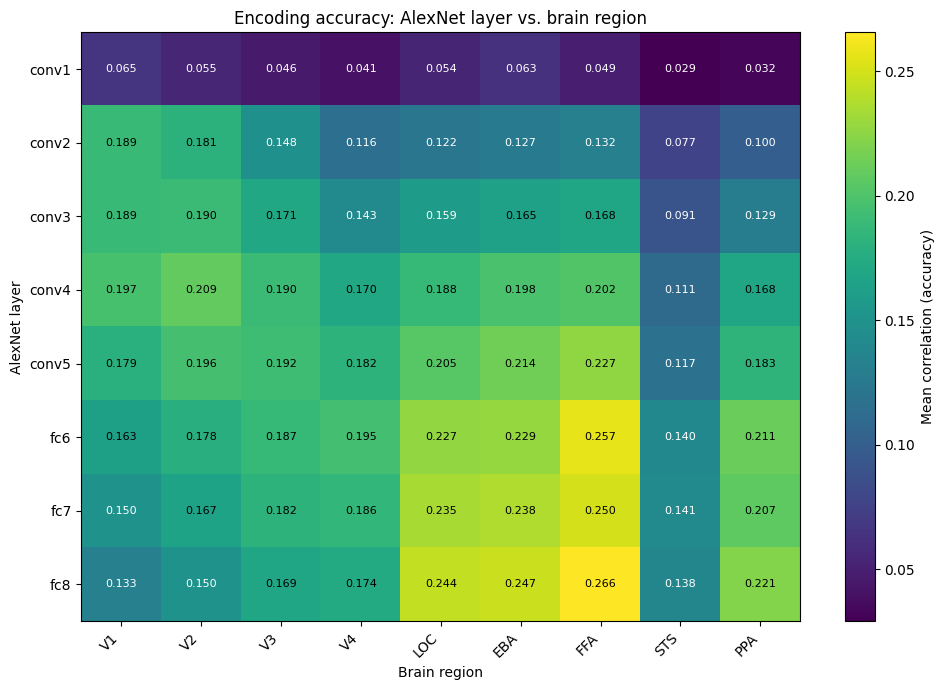

In [25]:
fig, ax = plt.subplots(figsize=(10, 7))

im = ax.imshow(pivot.values, aspect="auto", cmap="viridis")

ax.set_xticks(range(len(region_order)))
ax.set_xticklabels(region_order, rotation=45, ha="right")
ax.set_yticks(range(len(layer_order)))
ax.set_yticklabels(layer_order)

ax.set_xlabel("Brain region")
ax.set_ylabel("AlexNet layer")
ax.set_title("Encoding accuracy: AlexNet layer vs. brain region")

for i in range(len(layer_order)):
    for j in range(len(region_order)):
        val = pivot.values[i, j]
        ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                color="white" if val < pivot.values.max() * 0.6 else "black",
                fontsize=8)

fig.colorbar(im, ax=ax, label="Mean correlation (accuracy)")
fig.tight_layout()

import os
os.makedirs("results/figures/alexnet", exist_ok=True)
fig.savefig("results/figures/alexnet/layer_region_heatmap.png", dpi=150)

plt.show()

## Best layer per region

For each region, which layer predicts it best? This is the clearest
single summary of whether the hierarchy pattern holds.

In [26]:
best_layer_per_region = pivot.idxmax(axis=0)
best_accuracy_per_region = pivot.max(axis=0)

summary = pd.DataFrame({
    "best_layer": best_layer_per_region,
    "best_accuracy": best_accuracy_per_region,
})
summary = summary.reindex(region_order)
print(summary)

summary.to_csv("results/tables/alexnet/best_layer_per_region.csv")

       best_layer  best_accuracy
region                          
V1          conv4       0.197281
V2          conv4       0.209298
V3          conv5       0.192461
V4            fc6       0.195427
LOC           fc8       0.243977
EBA           fc8       0.246571
FFA           fc8       0.265666
STS           fc7       0.141158
PPA           fc8       0.221483


In [27]:
from google.colab import files

files.download("results/figures/alexnet/layer_region_heatmap.png")
files.download("results/tables/alexnet/best_layer_per_region.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>